# 01 · Preprocesamiento

Equivalente a `1_preprocess_dates.ipynb` + `2_limpiar_crear_chunks.ipynb` de Karen.
Réplica para la identificación del **marco COM-B** (Capacidad, Oportunidad, Motivación).

**Diferencia clave:** los tweets son cortos (~30 palabras), no artículos de miles de palabras.
Por eso no se aplica chunking solapado: **cada tweet = 1 chunk**.
El archivo `chunks.parquet` mantiene la misma estructura que el de Karen para que el resto del pipeline sea compatible.

**Fuente de datos:** `archivos/df_twitter.csv` (la misma de las replicaciones anteriores).
**Salidas:** `resultadosCOMB/corpus_cleaned.parquet` / `.xlsx`, `resultadosCOMB/chunks.parquet` / `.xlsx`.


In [1]:
# ============================================================
# CELL 0 - CONFIG
# ============================================================
from pathlib import Path

# -- Rutas ---------------------------------------------------
ARCHIVO_TWEETS = Path(r'C:\Users\afpue\Documents\GitHub\icare\archivos\df_twitter.csv')
DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB')

# Crear carpeta si no existe (pathlib.mkdir es confiable en Windows, sin subprocess)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print(f'[OK] DATA_PROCESSED : {DATA_PROCESSED}')
print(f'     Existe en disco : {DATA_PROCESSED.exists()}')

# -- Columnas del DataFrame ----------------------------------
COL_TEXTO       = 'Content'
COL_FECHA       = 'Fecha'
COL_DATE        = 'Date'
COL_AUTOR       = 'Author_Normalized'
COL_AUTOR_NAME  = 'Author Name'
COL_LOCATION    = 'Location'
COL_LIKES       = 'Number of Likes'
COL_RTS         = 'Number of Retweets'
COL_HASHTAGS    = 'Hashtags'
COL_MENTIONS    = 'Mentions'
COL_SENTIMIENTO = 'Sentimiento'
COL_POLARIDAD   = 'Polaridad'
COL_ENTIDAD     = 'Entidad'

print(f'  ARCHIVO_TWEETS : {ARCHIVO_TWEETS}')

[OK] DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB
     Existe en disco : True
  ARCHIVO_TWEETS : C:\Users\afpue\Documents\GitHub\icare\archivos\df_twitter.csv


In [2]:
# ============================================================
# CELL 1 - CARGA
# Equivalente a: corpus_completo = pd.read_excel(ruta_corpus)
# ============================================================
import pandas as pd

df = pd.read_csv(ARCHIVO_TWEETS, low_memory=False)
print(f'[CARGA] Leido desde disco: {ARCHIVO_TWEETS}')
print(f'  Filas    : {len(df):,}')
print(f'  Columnas : {list(df.columns)}')
df.head(3)

[CARGA] Leido desde disco: C:\Users\afpue\Documents\GitHub\icare\archivos\df_twitter.csv
  Filas    : 151,424
  Columnas : ['Author', 'Content', 'Date', 'Location', 'Number of Likes', 'Number of Retweets', 'In Reply To', 'Author Name', 'Author Description', 'Author Statuses Count', 'Author Favourites Count', 'Author Friends Count', 'Author Followers Count', 'Author Listed Count', 'Author Verified', 'Mentions', 'Hashtags', 'Content_cleaned', 'Content_cleaned_2', 'Seed_Set_1', 'In Reply To Normalized', 'Seed_Set_2', 'Seed_Set_2_Prob', 'Seed_Set_2_Model', 'Author_Normalized', 'Seed_Set_3', 'Entidad', 'Prob entidad', 'Polaridad', 'Fecha', 'Sentimiento']


,Author,Content,Date,Location,Number of Likes,Number of Retweets,In Reply To,Author Name,Author Description,Author Statuses Count,...,Seed_Set_2,Seed_Set_2_Prob,Seed_Set_2_Model,Author_Normalized,Seed_Set_3,Entidad,Prob entidad,Polaridad,Fecha,Sentimiento
0,@TReporta,VÍDEO| Reos que no están contagiados con COVID...,2020-06-03 18:56:24,NaN,0.0,0.0,NaN,Telemetro Reporta,Únete a la conversación y mantente informado c...,570708.0,...,0,0.427514,NB,@treporta,0,"Noticias locales, nacionales o globales",0.2946,Neutra,2020-06-03,otro
1,@annytak21,@IvanDuque @jaimepumarejo ya se enteraron de l...,2020-06-03 18:56:24,NaN,0.0,0.0,@IvanDuque,ANNA KAROLYNNA,NaN,233.0,...,0,0.505196,NB,@annytak21,1,Sin descripción,0.0000,Negativa,2020-06-03,otro
2,@ferumapress,El calvario de una familia en Cali por su mamá...,2020-06-03 18:56:17,NaN,0.0,0.0,NaN,Fernando Umaña Mejía,Periodista. Corresponsal de El Tiempo en Cali....,1674.0,...,1,0.999976,BERT,@ferumapress,0,"Noticias locales, nacionales o globales",0.5071,Negativa,2020-06-03,otro


In [3]:
# ============================================================
# CELL 2 - FECHAS
# Equivalente a: corpus_completo = utils.aplicar_funcion_fecha(corpus_completo)
# ============================================================

df[COL_FECHA] = pd.to_datetime(df[COL_FECHA], errors='coerce')
df[COL_DATE]  = pd.to_datetime(df[COL_DATE],  errors='coerce')

n_nulos = df[COL_FECHA].isna().sum()
print(f'[FECHAS] Tweets con fecha valida : {len(df) - n_nulos:,}')
print(f'[FECHAS] Tweets sin fecha        : {n_nulos:,}')
print(f'[FECHAS] Rango                   : {df[COL_FECHA].min()} -> {df[COL_FECHA].max()}')

df['anio']     = df[COL_FECHA].dt.year
df['mes']      = df[COL_FECHA].dt.month
# .astype(str) evita el tipo Period que pyarrow no serializa
df['anio_mes'] = df[COL_FECHA].dt.to_period('M').astype(str)

df[[COL_FECHA, COL_DATE, 'anio', 'mes', 'anio_mes']].head(3)

[FECHAS] Tweets con fecha valida : 151,424
[FECHAS] Tweets sin fecha        : 0
[FECHAS] Rango                   : 2020-03-31 00:00:00 -> 2020-08-18 00:00:00


,Fecha,Date,anio,mes,anio_mes
0,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06
1,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06
2,2020-06-03,2020-06-03 18:56:17,2020,6,2020-06


In [4]:
# ============================================================
# CELL 3 - LIMPIEZA
# Equivalente a: corpus = utils.aplicar_funcion_limpieza(corpus)
# ============================================================
import re

def limpiar_tweet(texto: str) -> str:
    """Limpia un tweet: quita RT, URLs, menciones, caracteres especiales."""
    if not isinstance(texto, str):
        return ''
    texto = re.sub(r'^RT\s+',                  '',  texto, flags=re.IGNORECASE)
    texto = re.sub(r'http\S+|www\S+|https\S+', ' ', texto)
    texto = re.sub(r'@\w+',                    ' ', texto)
    texto = re.sub(r'[^A-Za-z\u00e0-\u00ff\s\.\,\;\:\!\?\u00bf\u00a10-9]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['Texto_limpio'] = df[COL_TEXTO].apply(limpiar_tweet)

n_vacios = (df['Texto_limpio'].str.strip() == '').sum()
print(f'[LIMPIEZA] Tweets vacios tras limpieza : {n_vacios:,}')

df = df[df['Texto_limpio'].str.strip() != ''].reset_index(drop=True)
print(f'[LIMPIEZA] Tweets conservados          : {len(df):,}')

df['n_palabras'] = df['Texto_limpio'].str.split().str.len()
print(f"[LIMPIEZA] Palabras/tweet  media: {df['n_palabras'].mean():.1f}  "
      f"mediana: {df['n_palabras'].median():.0f}  "
      f"max: {df['n_palabras'].max()}")

df[[COL_TEXTO, 'Texto_limpio', 'n_palabras']].head(3)

[LIMPIEZA] Tweets vacios tras limpieza : 0
[LIMPIEZA] Tweets conservados          : 151,424
[LIMPIEZA] Palabras/tweet  media: 29.3  mediana: 30  max: 63


,Content,Texto_limpio,n_palabras
0,VÍDEO| Reos que no están contagiados con COVID...,VDEO Reos que no están contagiados con COVID19...,15
1,@IvanDuque @jaimepumarejo ya se enteraron de l...,ya se enteraron de la muerte supestamente por ...,24
2,El calvario de una familia en Cali por su mamá...,El calvario de una familia en Cali por su mamá...,14


In [5]:
# ============================================================
# CELL 4 - ID UNICO
# En utils.crear_chunks() del paper: id_doc = idx + 1
# ============================================================

df = df.reset_index(drop=True)
df['id_doc'] = df.index + 1

print(f"[ID] Rango id_doc : {df['id_doc'].min()} -> {df['id_doc'].max()}")
df[['id_doc', COL_AUTOR, COL_FECHA, 'Texto_limpio']].head(3)

[ID] Rango id_doc : 1 -> 151424


,id_doc,Author_Normalized,Fecha,Texto_limpio
0,1,@treporta,2020-06-03,VDEO Reos que no están contagiados con COVID19...
1,2,@annytak21,2020-06-03,ya se enteraron de la muerte supestamente por ...
2,3,@ferumapress,2020-06-03,El calvario de una familia en Cali por su mamá...


In [6]:
# ============================================================
# CELL 5 - GUARDAR CORPUS LIMPIO
# Equivalente a: corpus.to_excel(..., 'corpus_cleaned.xlsx') en Karen NB2
# ============================================================

COLS_CORPUS = [
    'id_doc',
    COL_AUTOR, COL_AUTOR_NAME, COL_FECHA, COL_DATE,
    'anio', 'mes', 'anio_mes',
    COL_LOCATION, COL_LIKES, COL_RTS,
    COL_HASHTAGS, COL_MENTIONS,
    COL_SENTIMIENTO, COL_POLARIDAD, COL_ENTIDAD,
    COL_TEXTO, 'Texto_limpio', 'n_palabras',
]
COLS_CORPUS = [c for c in COLS_CORPUS if c in df.columns]

corpus_limpio = df[COLS_CORPUS].copy()

ruta_parquet = DATA_PROCESSED / 'corpus_cleaned.parquet'
ruta_excel   = DATA_PROCESSED / 'corpus_cleaned.xlsx'

corpus_limpio.to_parquet(ruta_parquet, index=False, engine='pyarrow')
print(f'[GUARDADO] corpus_cleaned.parquet : {len(corpus_limpio):,} filas')

corpus_limpio.to_excel(ruta_excel, index=False, engine='openpyxl')
print(f'[GUARDADO] corpus_cleaned.xlsx    : {len(corpus_limpio):,} filas')
print(f'  Ruta: {DATA_PROCESSED}')

[GUARDADO] corpus_cleaned.parquet : 151,424 filas
[GUARDADO] corpus_cleaned.xlsx    : 151,424 filas
  Ruta: C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB


In [7]:
# ============================================================
# CELL 6 - CREAR CHUNKS
# Equivalente a: chunks_df = utils.crear_chunks(corpus, columna_texto='Texto_limpio',
#                                                tamano=150, solapamiento=20, umbral_minimo=100)
#
# DIFERENCIA con Karen: ella usa chunks solapados de 150 palabras porque trabaja
# con columnas de opinion (documentos largos). Los tweets tienen ~30 palabras
# -> cada tweet ES un chunk. Se mantiene la misma estructura de columnas para
# que el resto del pipeline (embeddings, BERTopic, etc.) funcione igual.
# ============================================================

cols_base = [
    'id_doc', COL_AUTOR, COL_AUTOR_NAME, COL_FECHA, COL_DATE,
    'anio', 'mes', 'anio_mes',
    COL_SENTIMIENTO, COL_POLARIDAD, COL_ENTIDAD,
    'Texto_limpio', 'n_palabras',
]
cols_base = [c for c in cols_base if c in corpus_limpio.columns]

chunks_df = corpus_limpio[cols_base].copy()

# Renombrar al esquema de Karen para compatibilidad downstream
chunks_df = chunks_df.rename(columns={
    COL_AUTOR:      'autor_doc',
    COL_AUTOR_NAME: 'nombre_autor_doc',
    COL_FECHA:      'fecha_doc',
    COL_DATE:       'date_doc',
    'Texto_limpio':  'texto_chunk',
    'n_palabras':    'n_palabras_chunk',
})

# Cada tweet = chunk 1 de 1
chunks_df['chunk_id']  = chunks_df['id_doc'].astype(str) + '_1'
chunks_df['num_chunk'] = 1

orden = [
    'id_doc', 'chunk_id', 'num_chunk',
    'autor_doc', 'nombre_autor_doc', 'fecha_doc', 'date_doc',
    'anio', 'mes', 'anio_mes',
    COL_SENTIMIENTO, COL_POLARIDAD, COL_ENTIDAD,
    'texto_chunk', 'n_palabras_chunk',
]
orden = [c for c in orden if c in chunks_df.columns]
chunks_df = chunks_df[orden].reset_index(drop=True)

print(f'[CHUNKS] Total chunks (= tweets) : {len(chunks_df):,}')
print(f'[CHUNKS] Columnas                : {list(chunks_df.columns)}')
print(f"[CHUNKS] Palabras/chunk  media: {chunks_df['n_palabras_chunk'].mean():.1f}  "
      f"mediana: {chunks_df['n_palabras_chunk'].median():.0f}  "
      f"max: {chunks_df['n_palabras_chunk'].max()}")
chunks_df.head(3)

[CHUNKS] Total chunks (= tweets) : 151,424
[CHUNKS] Columnas                : ['id_doc', 'chunk_id', 'num_chunk', 'autor_doc', 'nombre_autor_doc', 'fecha_doc', 'date_doc', 'anio', 'mes', 'anio_mes', 'Sentimiento', 'Polaridad', 'Entidad', 'texto_chunk', 'n_palabras_chunk']
[CHUNKS] Palabras/chunk  media: 29.3  mediana: 30  max: 63


,id_doc,chunk_id,num_chunk,autor_doc,nombre_autor_doc,fecha_doc,date_doc,anio,mes,anio_mes,Sentimiento,Polaridad,Entidad,texto_chunk,n_palabras_chunk
0,1,1_1,1,@treporta,Telemetro Reporta,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,otro,Neutra,"Noticias locales, nacionales o globales",VDEO Reos que no están contagiados con COVID19...,15
1,2,2_1,1,@annytak21,ANNA KAROLYNNA,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,otro,Negativa,Sin descripción,ya se enteraron de la muerte supestamente por ...,24
2,3,3_1,1,@ferumapress,Fernando Umaña Mejía,2020-06-03,2020-06-03 18:56:17,2020,6,2020-06,otro,Negativa,"Noticias locales, nacionales o globales",El calvario de una familia en Cali por su mamá...,14


[GUARDADO] chunks.parquet : 151,424 filas
[GUARDADO] chunks.xlsx    : 151,424 filas
Chunks exportados a Excel y Parquet.


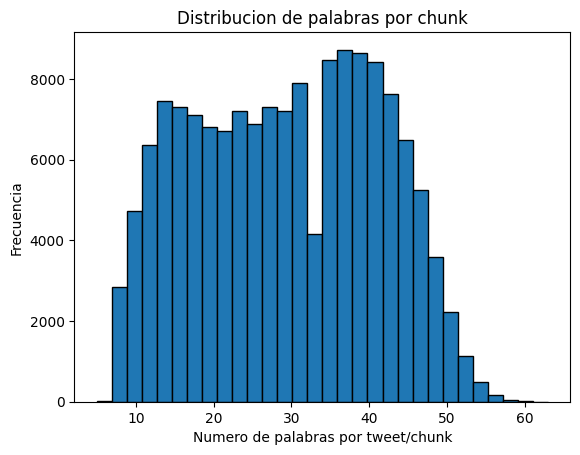

count    151424.000000
mean         29.262528
std          11.854403
min           5.000000
25%          19.000000
50%          30.000000
75%          39.000000
max          63.000000
Name: n_palabras_chunk, dtype: float64

In [8]:
# ============================================================
# CELL 7 - GUARDAR CHUNKS
# Equivalente a: chunks_df.to_excel / to_parquet en Karen NB2
# ============================================================

chunks_parquet_path = DATA_PROCESSED / 'chunks.parquet'
chunks_excel_path   = DATA_PROCESSED / 'chunks.xlsx'

chunks_df.to_parquet(chunks_parquet_path, index=False, engine='pyarrow')
print(f'[GUARDADO] chunks.parquet : {len(chunks_df):,} filas')

chunks_df.to_excel(chunks_excel_path, index=False, engine='openpyxl')
print(f'[GUARDADO] chunks.xlsx    : {len(chunks_df):,} filas')
print('Chunks exportados a Excel y Parquet.')

import matplotlib.pyplot as plt
plt.hist(chunks_df['n_palabras_chunk'], bins=30, edgecolor='black')
plt.xlabel('Numero de palabras por tweet/chunk')
plt.ylabel('Frecuencia')
plt.title('Distribucion de palabras por chunk')
plt.show()
chunks_df['n_palabras_chunk'].describe()

In [9]:
# ============================================================
# CELL 8 - VERIFICACION FINAL
# ============================================================
import os

print('=== RESUMEN NOTEBOOK 01 ===')
print(f'  Tweets tras limpieza  : {len(corpus_limpio):,}')
print(f'  Rango de fechas       : {corpus_limpio[COL_FECHA].min().date()} -> {corpus_limpio[COL_FECHA].max().date()}')
print(f'  Autores unicos        : {corpus_limpio[COL_AUTOR].nunique():,}')
print(f"  Media palabras/tweet  : {corpus_limpio['n_palabras'].mean():.1f}")
print()
print('  Archivos generados:')
for f in sorted(DATA_PROCESSED.iterdir()):
    size_kb = os.path.getsize(f) / 1024
    print(f'    {f.name:40s}  {size_kb:>8.1f} KB')
print()
print('Notebook 01 completado.')
print('Siguiente -> 02_estadisticos_corpus.ipynb')

=== RESUMEN NOTEBOOK 01 ===
  Tweets tras limpieza  : 151,424
  Rango de fechas       : 2020-03-31 -> 2020-08-18
  Autores unicos        : 79,938
  Media palabras/tweet  : 29.3

  Archivos generados:
    chunks.parquet                             23804.4 KB
    chunks.xlsx                                27235.0 KB
    corpus_cleaned.parquet                     47644.2 KB
    corpus_cleaned.xlsx                        36891.9 KB

Notebook 01 completado.
Siguiente -> 02_estadisticos_corpus.ipynb
